<a href="https://colab.research.google.com/github/DoraZKX1/AutomaticBoneAgePrediction/blob/master/ImageOnly_TabularOnly_Fusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# Densenet121
# download and inspect the dataset using Hugging Face Datasets library
# ============================================================
from datasets import load_dataset
ds = load_dataset("sandeep-shaw10/mendeley_knee_dxa")

print("=" * 60)
print("Dataset splits:", ds)
print("=" * 60)

split_name = list(ds.keys())[0]
print(f"\nColumns in '{split_name}':")
print(ds[split_name].features)

print("\nFirst example:")
ex = ds[split_name][0]
for k, v in ex.items():
    if hasattr(v, "size"):   # PIL image
        print(f"  {k}: PIL Image, size={v.size}, mode={v.mode}")
    else:
        print(f"  {k}: {repr(v)[:80]}")
print(f"Total examples: {len(ds[split_name])}")
# ============================================================
# config&setup
# ============================================================
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm
from collections import Counter
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from datasets import load_dataset
from PIL import Image

#config
IMAGE_COL = "image"
LABEL_COL = "label"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224 #rescale all images to 224x224
BATCH_SIZE = 16
EPOCHS_HEAD = 10 #train only the classifier head
#EPOCHS_FT = 8
SEED = 42  #set random seeds for reproducibility
torch.manual_seed(SEED); np.random.seed(SEED)

#take the image and label data from the "train" split of the dataset
data = ds["train"]
images = [ex[IMAGE_COL] for ex in data]
labels_raw = [ex[LABEL_COL] for ex in data]

#Label Encoding: Encode the string labels into integers
print("Raw label distribution:", Counter(labels_raw))
classes = sorted(set(labels_raw))
label_map = {c: i for i, c in enumerate(classes)}
print("Label mapping:", label_map)
labels = np.array([label_map[l] for l in labels_raw])
NUM_CLASSES = len(classes)
print(f"NUM_CLASSES = {NUM_CLASSES}")
print("Encoded distribution:", np.bincount(labels))

pids = [ex["patient_id"] for ex in data]
xrays = [ex["xray_code"] for ex in data]
print(f"Unique patient_id: {len(set(pids))} / Total: {len(pids)}")
print(f"Unique xray_code values: {Counter(xrays)}")
# ============================================================
# stochastic data augmentation
# ============================================================
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])
# ============================================================
# build model
# ============================================================
class KneeDataset(Dataset):
    def __init__(self, imgs, lbls, tf):
        self.imgs, self.lbls, self.tf = imgs, lbls, tf
    #return the total number of examples in the dataset
    def __len__(self): return len(self.imgs)
    #return the i-th image
    def __getitem__(self, i):
        img = self.imgs[i]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        return self.tf(img.convert("RGB")), int(self.lbls[i])
#build a DenseNet-121 model pretrained on ImageNet
def build_model():
    return timm.create_model("densenet121", pretrained=True, num_classes=NUM_CLASSES)

# ============================================================
# focal loss to deal with class imbalance
# ============================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma
    def forward(self, logits, targets):
        #compute the standard cross-entropy loss
        ce = nn.functional.cross_entropy(logits, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce)
        #return the mean focal loss over the batch
        return ((1 - pt) ** self.gamma * ce).mean()
from sklearn.metrics import recall_score

def run_epoch(model, loader, criterion, optimizer=None):
    #training with optimizer and evaluation without optimizer
    train = optimizer is not None
    model.train() if train else model.eval()
    all_logits, all_y, total_loss = [], [], 0.0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            #forward pass
            logits = model(x)
            #compute the loss
            loss = criterion(logits, y)
            if train:
                #if training, perform backpropagation and update the model parameters
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * x.size(0)
            all_logits.append(logits.detach().cpu()); all_y.append(y.cpu())
    #concatenate all logits and labels from the batches
    logits = torch.cat(all_logits); y = torch.cat(all_y)
    probs = torch.softmax(logits, dim=1).numpy()
    preds = probs.argmax(1)
    f1 = f1_score(y, preds, average="macro")
    try:
        auc = roc_auc_score(y, probs, multi_class="ovr", average="macro")
    except ValueError:
        auc = float("nan")
    rec = recall_score(y, preds, average=None,
                       labels=list(range(NUM_CLASSES)), zero_division=0)
    return total_loss / len(loader.dataset), f1, auc, rec
# ============================================================
# 5 fold stratified cross-validation -image-level split
# ============================================================
#create 5 folds stratified cross-validation on iamges
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

fold_f1, fold_auc,fold_rec = [], [],[]

for fold, (tr_idx, va_idx) in enumerate(skf.split(images, labels)):
    print(f"\n========== Fold {fold+1}/5 ==========")
    tr_imgs = [images[i] for i in tr_idx]; tr_lbls = labels[tr_idx]
    va_imgs = [images[i] for i in va_idx]; va_lbls = labels[va_idx]


    #WeightedRandomSampler oversamples minority classes so each batch is balanced
    sample_weights = (1.0 / np.bincount(tr_lbls))[tr_lbls]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    #load the training and validation data into PyTorch DataLoaders
    tr_loader = DataLoader(KneeDataset(tr_imgs, tr_lbls, train_tf),
                           batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
    va_loader = DataLoader(KneeDataset(va_imgs, va_lbls, val_tf),
                           batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    #build the model
    model = build_model().to(DEVICE)

    #cw = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=tr_lbls)
    #criterion = nn.CrossEntropyLoss(weight=torch.tensor(cw, dtype=torch.float).to(DEVICE))
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    #criterion = FocalLoss(alpha=torch.tensor(cw, dtype=torch.float).to(DEVICE), gamma=2.0)

    #stage 1: keep the pretrained backbone frozen and only train the classifier head for 8 epochs
    for p in model.parameters(): p.requires_grad = False
    for p in model.get_classifier().parameters(): p.requires_grad = True
    opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    best_f1, best_auc = 0.0, 0.0
    for ep in range(EPOCHS_HEAD):
        tl, _, _, _ = run_epoch(model, tr_loader, criterion, opt)
        vl, vf1, vauc, vrec= run_epoch(model, va_loader, criterion)
        if vf1 > best_f1: best_f1, best_auc, best_rec = vf1, vauc,vrec
        print(f"  [head] ep{ep+1:02d}  train_loss={tl:.3f}  val_f1={vf1:.3f}  val_auc={vauc:.3f}"
        f"rec[N={vrec[0]:.2f} OP={vrec[1]:.2f} OS={vrec[2]:.2f}]")
    fold_f1.append(best_f1); fold_auc.append(best_auc);fold_rec.append(best_rec)
    #stage 2: unfreeze the entire model and fine-tune it with a lower learning rate for 12 epochs
    """
    for p in model.parameters(): p.requires_grad = True
    opt = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS_FT)
    best_f1, best_auc = 0.0, 0.0
    for ep in range(EPOCHS_FT):
        tl, *_ = run_epoch(model, tr_loader, criterion, opt); sched.step()
        vl, vf1, vauc = run_epoch(model, va_loader, criterion)
        if vf1 > best_f1: best_f1, best_auc = vf1, vauc
        print(f"  ep{ep+1:02d}  train_loss={tl:.3f}  val_f1={vf1:.3f}  val_auc={vauc:.3f}")

    fold_f1.append(best_f1); fold_auc.append(best_auc)
    print(f"  >> Fold {fold+1}: F1={best_f1:.3f}  AUC={best_auc:.3f}")
    """
print("\n" + "=" * 40)
print(f"CV Macro-F1 : {np.mean(fold_f1):.3f} ± {np.std(fold_f1):.3f}")
print(f"CV Macro-AUC: {np.nanmean(fold_auc):.3f} ± {np.nanstd(fold_auc):.3f}")
recalls = np.array(fold_rec)
print(f"\nPer-class recall:")
print(f"  N : {recalls.mean(0)[0]:.2f} ± {recalls.std(0)[0]:.2f}")
print(f"  OP: {recalls.mean(0)[1]:.2f} ± {recalls.std(0)[1]:.2f}")
print(f"  OS: {recalls.mean(0)[2]:.2f} ± {recalls.std(0)[2]:.2f}")
print("=" * 40)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/10.6k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/183M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/239 [00:00<?, ? examples/s]

Dataset splits: DatasetDict({
    train: Dataset({
        features: ['filename', 'image', 'label', 'patient_id', 'patient_code', 'xray_code', 's.no', 'joint_pain', 'gender', 'age', 'menopause_age', 'height__(meter)', 'weight_(kg)', 'smoker', 'alcoholic', 'diabetic', 'hypothyroidism', 'number_of_pregnancies', 'seizer_disorder', 'estrogen_use', 'occupation', 'history_of_fracture', 'dialysis', 'family_history_of_osteoporosis', 'maximum_walking_distance_(km)', 'daily_eating_habits', 'medical_history', 't-score_value', 'z-score_value', 'bmi', 'obesity'],
        num_rows: 239
    })
})

Columns in 'train':
{'filename': Value('string'), 'image': Image(mode=None, decode=True), 'label': Value('string'), 'patient_id': Value('int64'), 'patient_code': Value('string'), 'xray_code': Value('string'), 's.no': Value('float64'), 'joint_pain': Value('string'), 'gender': Value('string'), 'age': Value('float64'), 'menopause_age': Value('float64'), 'height__(meter)': Value('float64'), 'weight_(kg)': Value

model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

  [head] ep01  train_loss=1.134  val_f1=0.262  val_auc=0.497rec[N=0.50 OP=0.47 OS=0.00]
  [head] ep02  train_loss=1.110  val_f1=0.341  val_auc=0.540rec[N=0.25 OP=0.57 OS=0.20]
  [head] ep03  train_loss=1.091  val_f1=0.224  val_auc=0.714rec[N=1.00 OP=0.10 OS=0.10]
  [head] ep04  train_loss=1.114  val_f1=0.347  val_auc=0.736rec[N=0.75 OP=0.13 OS=0.50]
  [head] ep05  train_loss=1.069  val_f1=0.328  val_auc=0.693rec[N=0.75 OP=0.13 OS=0.50]
  [head] ep06  train_loss=1.074  val_f1=0.419  val_auc=0.628rec[N=0.50 OP=0.73 OS=0.10]
  [head] ep07  train_loss=1.027  val_f1=0.380  val_auc=0.593rec[N=0.62 OP=0.47 OS=0.20]
  [head] ep08  train_loss=1.016  val_f1=0.391  val_auc=0.619rec[N=0.25 OP=0.83 OS=0.10]
  [head] ep09  train_loss=1.035  val_f1=0.358  val_auc=0.627rec[N=0.75 OP=0.37 OS=0.20]
  [head] ep10  train_loss=1.110  val_f1=0.415  val_auc=0.644rec[N=0.25 OP=0.77 OS=0.20]

========== Fold 2/5 ==========
  [head] ep01  train_loss=1.146  val_f1=0.259  val_auc=0.461rec[N=0.43 OP=0.52 OS=0.00]


In [5]:
# ============================================================
# ResNet Patching
# ============================================================
from sklearn.metrics import accuracy_score
from torchvision.models import resnet50
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm
from collections import Counter
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from datasets import load_dataset
from PIL import Image
import torch
import pandas as pd
IMAGE_COL = "image"
LABEL_COL = "label"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS_HEAD = 8
EPOCHS_FT = 12
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

# ============================================================
# Loading the Mendeley Knee DXA dataset
# ============================================================
raw = load_dataset("sandeep-shaw10/mendeley_knee_dxa")
data = raw["train"]

images = [ex[IMAGE_COL] for ex in data]
labels_raw = [ex[LABEL_COL] for ex in data]


# ============================================================
# Creating a patch-based PyTorch dataset for knee X-ray images
# ============================================================

class PatchKneeDataset(Dataset):
    def __init__(self, imgs, lbls, tf, n_patches=4):
        self.imgs = imgs
        self.lbls = lbls
        self.tf = tf
        self.n_patches = n_patches

    def __len__(self):
        return len(self.imgs) * self.n_patches

    def __getitem__(self, idx):
        img_idx = idx // self.n_patches
        patch_idx = idx % self.n_patches

        img = self.imgs[img_idx]

        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))

        img = img.convert("RGB")

        w, h = img.size

        # Divide image into 4 fixed patches
        boxes = [
            (0, 0, w // 2, h // 2),        # top-left
            (w // 2, 0, w, h // 2),        # top-right
            (0, h // 2, w // 2, h),        # bottom-left
            (w // 2, h // 2, w, h),        # bottom-right
        ]

        patch = img.crop(boxes[patch_idx])

        label = int(self.lbls[img_idx])

        return self.tf(patch), label

# ============================================================
# Encoding class labels and examining class distribution
# ============================================================
print("Raw label distribution:", Counter(labels_raw))
classes = sorted(set(labels_raw))
label_map = {c: i for i, c in enumerate(classes)}
print("Label mapping:", label_map)
labels = np.array([label_map[l] for l in labels_raw])
NUM_CLASSES = len(classes)
print(f"NUM_CLASSES = {NUM_CLASSES}")
print("Encoded distribution:", np.bincount(labels))

# ============================================================
# Defining image preprocessing and augmentation pipelines
# ============================================================

NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])


val_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])


# ============================================================
# Creating a custom PyTorch dataset for knee X-ray images
# ============================================================

class KneeDataset(Dataset):
    def __init__(self, imgs, lbls, tf):
        self.imgs, self.lbls, self.tf = imgs, lbls, tf
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        img = self.imgs[i]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        return self.tf(img.convert("RGB")), int(self.lbls[i])


def build_model():
    model = resnet50(weights="IMAGENET1K_V2")

    model.fc = nn.Linear(
        model.fc.in_features,
        NUM_CLASSES
    )

    return model

# ============================================================
# Defining the Focal Loss implementation for comparison
# ============================================================

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma
    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(logits, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

# ============================================================
# Training and evaluating the model for one epoch
# ============================================================

def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    all_logits, all_y, total_loss = [], [], 0.0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss = criterion(logits, y)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * x.size(0)
            all_logits.append(logits.detach().cpu()); all_y.append(y.cpu())
    logits = torch.cat(all_logits); y = torch.cat(all_y)
    probs = torch.softmax(logits, dim=1).numpy()
    preds = probs.argmax(1)
    f1 = f1_score(y, preds, average="macro")
    acc = accuracy_score(y, preds)
    try:
        auc = roc_auc_score(y, probs, multi_class="ovr", average="macro")
    except ValueError:
        auc = float("nan")
    return total_loss / len(loader.dataset), f1, auc, acc

# ============================================================
# Performing stratified 5-fold cross-validation
# ============================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fold_f1, fold_auc = [], []

all_probabilities = [] #my addition
fold_acc = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(images, labels)):
    print(f"\n========== Fold {fold+1}/5 ==========")
    tr_imgs = [images[i] for i in tr_idx]; tr_lbls = labels[tr_idx]
    va_imgs = [images[i] for i in va_idx]; va_lbls = labels[va_idx]

# ============================================================
# Creating training and validation data loaders
# ===========================================================

    # tr_loader = DataLoader(KneeDataset(tr_imgs, tr_lbls, train_tf),
    #                        batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    # va_loader = DataLoader(KneeDataset(va_imgs, va_lbls, val_tf),
    #                        batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    tr_loader = DataLoader(
        PatchKneeDataset(tr_imgs, tr_lbls, train_tf, n_patches=4),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0
)

    va_loader = DataLoader(
        PatchKneeDataset(va_imgs, va_lbls, val_tf, n_patches=4),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0
    )

# ============================================================
# Computing class weights and defining the loss function
# ============================================================

    model = build_model().to(DEVICE)
    print(type(model).__name__)
    cw = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=tr_lbls)
    # criterion = FocalLoss(alpha=None, gamma=2.0)
    # criterion = FocalLoss(alpha=torch.tensor(cw, dtype=torch.float).to(DEVICE), gamma=2.0)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(cw, dtype=torch.float).to(DEVICE))

# ============================================================
# Training the classifier head using transfer learning
# ============================================================
    for p in model.parameters(): p.requires_grad = False
    # for p in model.get_classifier().parameters(): p.requires_grad = True
    for p in model.fc.parameters(): p.requires_grad = True
    opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    for ep in range(EPOCHS_HEAD):
        run_epoch(model, tr_loader, criterion, opt)

# ============================================================
# Fine-tuning the full ResNet model
# ============================================================

    for p in model.parameters(): p.requires_grad = True
    opt = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS_FT)
    best_f1, best_auc, best_acc = 0.0, 0.0, 0.0

# ============================================================
# Tracking validation performance across epochs
# ============================================================
    for ep in range(EPOCHS_FT):
        tl, *_ = run_epoch(model, tr_loader, criterion, opt); sched.step()
        vl, vf1, vauc, vacc = run_epoch(model, va_loader, criterion)
        if vf1 > best_f1: best_f1, best_auc, best_acc = vf1, vauc, vacc
        #print(f"  ep{ep+1:02d}  train_loss={tl:.3f}  val_f1={vf1:.3f}  val_auc={vauc:.3f} val_acc={vacc:.3f}")
        print(
            f"  ep{ep+1:02d} "
            f"train_loss={tl:.3f} "
            f"val_acc={vacc:.3f} "
            f"val_f1={vf1:.3f} "
            f"val_auc={vauc:.3f}"
)

    # fold_f1.append(best_f1); fold_auc.append(best_auc)
    # fold_acc.append(best_acc)
    # print(f"  >> Fold {fold+1}: F1={best_f1:.3f}  AUC={best_auc:.3f}")
    print(f"  >> Fold {fold+1}: " f"ACC={best_acc:.3f} " f"F1={best_f1:.3f} " f"AUC={best_auc:.3f}")

    # Save validation probabilities for this fold: #my addition

# ============================================================
# Saving fold-level prediction probabilities
# ============================================================


    model.eval()
    fold_probs = []
    fold_preds = []
    fold_true = []


    with torch.no_grad():
      for x, y in va_loader:
          x = x.to(DEVICE)
          logits = model(x)
          probs = torch.softmax(logits, dim=1).cpu().numpy()
          preds = probs.argmax(axis=1)

          fold_probs.append(probs)
          fold_preds.append(preds)
          fold_true.append(y.numpy())

    # fold_probs = np.vstack(fold_probs)
    # fold_preds = np.concatenate(fold_preds)
    # fold_true = np.concatenate(fold_true)

    fold_probs = np.vstack(fold_probs)
    fold_true = np.concatenate(fold_true)

    # 4 patches per image
    N_PATCHES = 4

    # Average probabilities across patches
    fold_probs = fold_probs.reshape(-1, N_PATCHES, NUM_CLASSES).mean(axis=1)

    # One prediction per original image
    fold_preds = fold_probs.argmax(axis=1)

    # Keep one label per original image
    fold_true = fold_true.reshape(-1, N_PATCHES)[:, 0]

    image_f1 = f1_score(fold_true, fold_preds, average="macro")
    image_acc = accuracy_score(fold_true, fold_preds)

    try:
        image_auc = roc_auc_score(
            fold_true,
            fold_probs,
            multi_class="ovr",
            average="macro"
        )
    except ValueError:
        image_auc = float("nan")

    best_f1 = image_f1
    best_auc = image_auc
    best_acc = image_acc

    fold_f1.append(best_f1)
    fold_auc.append(best_auc)
    fold_acc.append(best_acc)

# ============================================================
# Analyzing prediction and class distributions
# ============================================================

    print(f"\nFold {fold+1} prediction distribution:")
    print(Counter(fold_preds))

    print(f"Fold {fold+1} true distribution:")
    print(Counter(fold_true))

# ============================================================
# Storing patient-level image probabilities for fusion
# ============================================================

    fold_df = pd.DataFrame({
        "dataset_index": va_idx,
        "fold": fold + 1,
        "true_label": fold_true,
        "pred_label": fold_preds,
        "prob_N": fold_probs[:, 0],
        "prob_OP": fold_probs[:, 1],
        "prob_OS": fold_probs[:, 2],
})

    print(f"\nFold {fold+1} mapping check:")
    print(fold_df[["dataset_index", "true_label", "pred_label","prob_N", "prob_OP", "prob_OS"]].head(5))

    all_probabilities.append(fold_df)



# ============================================================
# Reporting cross-validation performance metrics
# ============================================================


print("\n" + "=" * 40)
print(f"CV Macro-F1 : {np.mean(fold_f1):.3f} ± {np.std(fold_f1):.3f}")
print(f"CV Macro-AUC: {np.nanmean(fold_auc):.3f} ± {np.nanstd(fold_auc):.3f}")
print(f"CV Accuracy : {np.mean(fold_acc):.3f} ± {np.std(fold_acc):.3f}")
print("=" * 40)

# image_probabilities = pd.concat(all_probabilities, ignore_index=True)

image_probabilities = (
    pd.concat(all_probabilities)
    .sort_values("dataset_index")
    .reset_index(drop=True)
)

# ============================================================
# Exporting image probabilities for late-fusion experiments
# ============================================================

image_probabilities.to_csv(
    "image_probabilities_5fold.csv",
    index=False
)

print("Saved probabilities to image_probabilities_5fold.csv")
print(image_probabilities.head())

print("\nFinal image probabilities check:")
print(image_probabilities.head())
print(image_probabilities.tail())

print("Rows:", len(image_probabilities))
print("Unique indices:", image_probabilities["dataset_index"].nunique())

Raw label distribution: Counter({'OP': 154, 'OS': 49, 'N': 36})
Label mapping: {'N': 0, 'OP': 1, 'OS': 2}
NUM_CLASSES = 3
Encoded distribution: [ 36 154  49]

========== Fold 1/5 ==========
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 223MB/s]


ResNet
  ep01 train_loss=1.005 val_acc=0.557 val_f1=0.467 val_auc=0.645
  ep02 train_loss=0.989 val_acc=0.562 val_f1=0.458 val_auc=0.630
  ep03 train_loss=0.978 val_acc=0.552 val_f1=0.465 val_auc=0.645
  ep04 train_loss=0.956 val_acc=0.505 val_f1=0.429 val_auc=0.619
  ep05 train_loss=0.950 val_acc=0.562 val_f1=0.464 val_auc=0.623
  ep06 train_loss=0.927 val_acc=0.521 val_f1=0.448 val_auc=0.632
  ep07 train_loss=0.936 val_acc=0.495 val_f1=0.432 val_auc=0.618
  ep08 train_loss=0.925 val_acc=0.510 val_f1=0.426 val_auc=0.629
  ep09 train_loss=0.926 val_acc=0.516 val_f1=0.442 val_auc=0.625
  ep10 train_loss=0.909 val_acc=0.500 val_f1=0.425 val_auc=0.615
  ep11 train_loss=0.903 val_acc=0.521 val_f1=0.445 val_auc=0.619
  ep12 train_loss=0.918 val_acc=0.510 val_f1=0.438 val_auc=0.608
  >> Fold 1: ACC=0.557 F1=0.467 AUC=0.645

Fold 1 prediction distribution:
Counter({np.int64(1): 33, np.int64(2): 9, np.int64(0): 6})
Fold 1 true distribution:
Counter({np.int64(1): 30, np.int64(2): 10, np.int64(0

In [1]:
def clean_tabular(df):
    """
    Clean and feature-engineer the raw Mendeley knee DXA tabular data.

    Parameters
    ----------
    df : pd.DataFrame
        Raw DataFrame from ds["train"].to_pandas(), containing 239 rows
        and all original columns (filename, image, label, patient_id, 25
        clinical features, t-score, z-score, etc.)

    Returns
    -------
    X : pd.DataFrame
        Cleaned feature matrix with 17 engineered features
    y : pd.Series
        Labels ('N', 'OP', 'OS')
    feature_groups : dict
        {'numeric': [...], 'categorical': [...], 'binary': [...]}
        For use with the preprocessing ColumnTransformer downstream.
    """
    df = df.copy()
    # ---------- 1. Drop identifiers and leakage features ----------
    # t-score, z-score directly encode the label (T < -2.5 → osteoporosis)
    # filename / image / patient_code / xray_code are identifiers
    drop_cols = [
        "filename", "image", "patient_id", "patient_code", "xray_code", "s.no",
        "t-score_value", "z-score_value", "label"
    ]
    X = df.drop(columns=drop_cols, errors="ignore")
    y = df["label"]

    # ---------- 2. Drop low-variance / near-constant features ----------
    drop_low_variance = ["alcoholic", "dialysis", "joint_pain"]
    X = X.drop(columns=drop_low_variance, errors="ignore")

    # ---------- 3. Menopause-related engineered features ----------
    # years_since_menopause: clinically meaningful predictor (post-menopause = higher risk)
    # Negative values clipped to 0 (still pre-menopause)
    X["years_since_menopause"] = (X["age"] - X["menopause_age"]).clip(lower=0).fillna(0)

    # ---------- 4. Pregnancy-related engineered features ----------
    # Male patients cannot have pregnancies → force to 0 (avoid spurious NaN)
    X["number_of_pregnancies"] = X["number_of_pregnancies"].fillna(0)
    X.loc[X["gender"] == "Male", "number_of_pregnancies"] = 0

    # ---------- 5. Occupation → physical activity level ----------
    # Step A: Standardize inconsistent occupation labels
    X["occupation"] = X["occupation"].replace({
        "businesman": "businessman",
        "bussinesman": "businessman",
        "R.G.E": "Retired",
        "R.N T": "Retired",
        "R.g.e": "Retired",
        "R.Police": "Retired",
        "R.lecturer": "Retired",
        "Teacher": "teacher",
        "lecturer": "teacher",
    })
    X["occupation"] = X["occupation"].fillna("Unknown")

    # Step B: Map raw occupations to 4 clinically meaningful activity levels
    activity_map = {
        "Unknown": "Unknown",
        # High physical activity
        "farmer": "High", "labour": "High", "carpenter": "High",
        "forest guard": "High", "worker": "High", "chopan": "High", "nurse": "High",
        # Moderate physical activity
        "teacher": "Moderate", "health worker": "Moderate", "h.wife": "Moderate",
        "businessman": "Moderate", "G.E": "Moderate", "shopkeeper": "Moderate",
        "barber": "Moderate", "mobile technician": "Moderate",
        "student": "Moderate", "plumber": "Moderate",
        # Low physical activity
        "clerk": "Low", "stenographer": "Low", "Retired": "Low",
    }
    X["physical_activity_level"] = X["occupation"].map(activity_map).fillna("Unknown")

    # ---------- 6. Fracture history → severity categories ----------
    # Major fractures (hip, vertebral, neck) are stronger osteoporosis indicators
    # Minor fractures (wrist, ankle, etc.) are weaker but still relevant
    def fracture_severity(x):
        x = str(x).lower().strip()
        if x == "no":
            return "No fracture"
        if x == "yes":
            return "Unknown fracture"
        major = ["hip", "vertebral", "lumbar", "spinal", "neck"]
        minor = ["wrist", "ankle", "foot", "arm", "elbow", "shoulder",
                 "leg", "knee", "collar", "hand", "head"]
        if any(w in x for w in major):
            return "Major"
        if any(w in x for w in minor):
            return "Minor"
        return "Other"

    X["fracture_severity"] = X["history_of_fracture"].apply(fracture_severity)

    # ---------- 7. Medical history → 4 binary disease group flags ----------
    # Free-text medical_history is noisy → split into clinically grouped binaries
    medical = X["medical_history"].fillna("").str.lower()

    disease_groups = {
        "has_cardiovascular": [
            "b.p", "bp", "hypertnsn", "cardiac", "heart", "low b.p", "stunt"
        ],
        "has_musculoskeletal": [
            "disk", "arthritis", "arthrities", "r.arthritis", "vertebral",
            "kyphotic", "posture", "osteoporosis", "osteopenia", "gout",
            "neck disk", "l.ankle", "ankle"
        ],
        "has_metabolic": [
            "cholestrol", "fatty liver", "uric acid", "tg", "cirhosis",
            "liver cyst", "kidney"
        ],
        "has_gynecological": [
            "uterus", "ovary", "f.tube", "scizerian", "seizerian", "sciserian",
            "sezerian", "breast", "pcod"
        ],
    }

    for group_name, terms in disease_groups.items():
        X[group_name] = medical.apply(
            lambda x: int(any(term in x for term in terms))
        )

    # ---------- 8. Drop the columns we've now transformed ----------
    cols_to_drop = [
        "history_of_fracture",       # → fracture_severity
        "daily_eating_habits",        # too noisy, low signal
        "height__(meter)",            # → captured by BMI
        "weight_(kg)",                # → captured by BMI
        "seizer_disorder",            # very rare, near-constant
        "obesity",                    # → captured by BMI
        "menopause_age",              # → years_since_menopause
        "occupation",                 # → physical_activity_level
        "medical_history",            # → 4 binary group flags
    ]
    X = X.drop(columns=cols_to_drop, errors="ignore")

    # ---------- 9. Standardize binary yes/no fields to 1/0 ----------
    binary_cols = [
        "smoker", "diabetic", "hypothyroidism",
        "family_history_of_osteoporosis", "estrogen_use",
    ]
    for col in binary_cols:
        X[col] = (
            X[col].astype(str).str.lower().str.strip()
                  .map({"yes": 1, "no": 0})
        )

    # ---------- 10. Define feature groups for downstream preprocessor ----------
    feature_groups = {
        "numeric": [
            "age",
            "number_of_pregnancies",
            "maximum_walking_distance_(km)",
            "bmi",
            "years_since_menopause",
        ],
        "categorical": [
            "gender",
            "physical_activity_level",
            "fracture_severity",
        ],
        "binary": [
            "smoker", "diabetic", "hypothyroidism",
            "estrogen_use", "family_history_of_osteoporosis",
            "has_cardiovascular", "has_musculoskeletal",
            "has_metabolic", "has_gynecological",
        ],
    }

    return X, y, feature_groups

def build_preprocessor(feature_groups, scale_numeric=False):
    """
    Build the sklearn ColumnTransformer for tabular features.

    Parameters
    ----------
    feature_groups : dict
        Output from clean_tabular(), containing 'numeric', 'categorical', 'binary'.
    scale_numeric : bool
        If True, apply StandardScaler to numeric and binary features (needed for MLP).
        If False, only impute (suitable for tree models like XGBoost).

    Returns
    -------
    preprocessor : ColumnTransformer
        Ready to be used in a Pipeline or fit_transform directly.
    """
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler

    if scale_numeric:
        numeric_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ])
        binary_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("scaler", StandardScaler()),
        ])
    else:
        numeric_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ])
        binary_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
        ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, feature_groups["numeric"]),
        ("cat", categorical_transformer, feature_groups["categorical"]),
        ("bin", binary_transformer, feature_groups["binary"]),
    ])

    return preprocessor

In [2]:
# ============================================================
# Tabular-Only Baseline: Random Forest with Row-Level 5-Fold CV
# ============================================================
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, roc_auc_score, recall_score
from datasets import load_dataset

# ---------- 1. Load data and apply cleaning function ----------
ds = load_dataset("sandeep-shaw10/mendeley_knee_dxa")
df = ds["train"].to_pandas()

X, y, feature_groups = clean_tabular(df)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
NUM_CLASSES = len(label_encoder.classes_)
print(f"Label mapping: {dict(zip(label_encoder.classes_, range(NUM_CLASSES)))}")
print(f"Total samples: {len(X)}, features: {X.shape[1]}")
print(f"Class distribution: {np.bincount(y_encoded)}")

# ---------- 2. Row-level stratified 5-fold split ----------
# StratifiedKFold preserves class proportions in each fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------- 3. Storage for out-of-fold predictions ----------
# These OOF probabilities are saved for downstream fusion analysis.
all_va_probs = np.zeros((len(X), NUM_CLASSES))
fold_f1, fold_auc, fold_rec = [], [], []

# ---------- 4. 5-fold cross-validation loop ----------
for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y_encoded)):
    print(f"\n========== Fold {fold+1}/5 ==========")

    # Extract train / val splits for this fold
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y_encoded[tr_idx], y_encoded[va_idx]
    print(f"  Train: {len(tr_idx)} rows  Val: {len(va_idx)} rows")
    print(f"  Train dist: {np.bincount(y_tr)}  Val dist: {np.bincount(y_va)}")

    # Preprocessing
    preprocessor = build_preprocessor(feature_groups, scale_numeric=False)
    X_tr_proc = preprocessor.fit_transform(X_tr)
    X_va_proc = preprocessor.transform(X_va)

    #Random Forest classifier
    rf = RandomForestClassifier(
        n_estimators=300, #ensemble size
        max_depth=8,#bound tree complexity
        min_samples_split=4,
        min_samples_leaf=2,#prevents single-sample leaves
        max_features="sqrt",#standard RF heuristic
        class_weight="balanced",#built-in handling of class imbalance
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_tr_proc, y_tr)

    #Predict validation probabilities
    va_probs = rf.predict_proba(X_va_proc)
    va_preds = va_probs.argmax(1)

    #Store this fold's val probabilities in the global OOF array
    all_va_probs[va_idx] = va_probs

    #Compute per-fold metrics
    f1 = f1_score(y_va, va_preds, average="macro")
    try:
        auc = roc_auc_score(y_va, va_probs, multi_class="ovr", average="macro")
    except ValueError:
        # AUC undefined if a class is absent from this val fold
        auc = float("nan")
    rec = recall_score(y_va, va_preds, average=None,
                       labels=list(range(NUM_CLASSES)), zero_division=0)

    print(f"  Fold {fold+1}: F1={f1:.3f}  AUC={auc:.3f}  "
          f"rec[N={rec[0]:.2f} OP={rec[1]:.2f} OS={rec[2]:.2f}]")

    fold_f1.append(f1)
    fold_auc.append(auc)
    fold_rec.append(rec)

# ---------- 5. Cross-validation summary ----------
print("\n" + "=" * 55)
print("Tabular-Only (Random Forest) — Row-Level 5-Fold CV")
print("=" * 55)
print(f"  Macro-F1 : {np.mean(fold_f1):.3f} ± {np.std(fold_f1):.3f}")
print(f"  Macro-AUC: {np.nanmean(fold_auc):.3f} ± {np.nanstd(fold_auc):.3f}")

recalls = np.array(fold_rec)
print(f"  Per-class recall:")
print(f"    N : {recalls.mean(0)[0]:.2f} ± {recalls.std(0)[0]:.2f}")
print(f"    OP: {recalls.mean(0)[1]:.2f} ± {recalls.std(0)[1]:.2f}")
print(f"    OS: {recalls.mean(0)[2]:.2f} ± {recalls.std(0)[2]:.2f}")
print("=" * 55)

# ---------- 6. Save OOF predictions for downstream fusion ----------
np.save("tabular_rf_oof_probs.npy", all_va_probs)
print(f"\nSaved OOF probabilities: shape {all_va_probs.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/10.6k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/183M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/239 [00:00<?, ? examples/s]

Label mapping: {'N': 0, 'OP': 1, 'OS': 2}
Total samples: 239, features: 17
Class distribution: [ 36 154  49]

========== Fold 1/5 ==========
  Train: 191 rows  Val: 48 rows
  Train dist: [ 28 124  39]  Val dist: [ 8 30 10]
  Fold 1: F1=0.627  AUC=0.834  rec[N=0.88 OP=0.53 OS=0.60]

========== Fold 2/5 ==========
  Train: 191 rows  Val: 48 rows
  Train dist: [ 29 123  39]  Val dist: [ 7 31 10]
  Fold 2: F1=0.691  AUC=0.912  rec[N=1.00 OP=0.74 OS=0.50]

========== Fold 3/5 ==========
  Train: 191 rows  Val: 48 rows
  Train dist: [ 29 123  39]  Val dist: [ 7 31 10]
  Fold 3: F1=0.762  AUC=0.865  rec[N=0.86 OP=0.90 OS=0.50]

========== Fold 4/5 ==========
  Train: 191 rows  Val: 48 rows
  Train dist: [ 29 123  39]  Val dist: [ 7 31 10]
  Fold 4: F1=0.643  AUC=0.779  rec[N=0.57 OP=0.87 OS=0.40]

========== Fold 5/5 ==========
  Train: 192 rows  Val: 47 rows
  Train dist: [ 29 123  40]  Val dist: [ 7 31  9]
  Fold 5: F1=0.640  AUC=0.837  rec[N=0.86 OP=0.65 OS=0.56]

Tabular-Only (Random Fore

In [11]:
# ============================================================
# Three-Way Comparison: Image-only vs Tabular-only vs Concat Fusion
#
# Image-only:      MLP trained on frozen DenseNet-121 embeddings (1024-d)
# Tabular-only:    MLP trained on cleaned + scaled tabular features
# Concat Fusion:   MLP trained on the concatenation of projected image
#                  embedding (32-d) and tabular features
#
# All three branches share:
#   - The same 5-fold split (random_state=42)
#   - The same training recipe (class-weighted CE, label smoothing,
#     AdamW + cosine LR, dropout=0.4)
#   - The same number of epochs
# This makes the comparison apples-to-apples: any performance
# difference is attributable to the input representation, not to
# architectural or optimization differences.
# ============================================================
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
import timm

FUSION_EPOCHS = 50
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


# ============================================================
# 1. Extract image embeddings once (frozen DenseNet-121 backbone)
# ============================================================
def extract_image_embeddings(images):
    """Run all images through frozen DenseNet-121; return [N, 1024]."""
    model = timm.create_model("densenet121", pretrained=True, num_classes=0)
    model = model.to(DEVICE).eval()
    loader = DataLoader(
        KneeDataset(images, [0] * len(images), val_tf),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
    )
    feats = []
    with torch.no_grad():
        for x, _ in loader:
            feats.append(model(x.to(DEVICE)).cpu().numpy())
    return np.concatenate(feats, 0)


print("Extracting image embeddings (frozen DenseNet-121)...")
img_embeddings = extract_image_embeddings(images)
print(f"Image embeddings shape: {img_embeddings.shape}")


# ============================================================
# 2. Unified MLP class — handles all three branches
# ============================================================
# A single class handles all three input configurations by toggling
# the image projection and the tabular concatenation. This keeps the
# training recipe identical across branches.
class BranchMLP(nn.Module):
    """
    Flexible MLP for image-only, tabular-only, or concat-fusion input.

    Modes (selected by which features are non-None at forward time):

        image-only:  image_embed (1024-d) -> proj (32-d) -> head -> 3 logits
        tabular:                              tab (~25-d) -> head -> 3 logits
        concat:      [proj(image) (32-d) ; tab (~25-d)] -> head -> 3 logits

    Heavy dropout (0.4) is used because n=239 is small.
    """
    def __init__(self, img_dim=None, tab_dim=None, hidden=64,
                 n_class=3, dropout=0.4):
        super().__init__()
        self.use_img = img_dim is not None
        self.use_tab = tab_dim is not None

        # Image projection (only created if image input is used).
        # Projects 1024-d image embedding down to 32-d so it does not
        # dominate the tabular vector when concatenated.
        if self.use_img:
            self.img_proj = nn.Sequential(
                nn.Linear(img_dim, 64), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(64, 32),      nn.ReLU(), nn.Dropout(dropout),
            )
            img_out = 32
        else:
            img_out = 0

        tab_out = tab_dim if self.use_tab else 0

        # Shared classifier head: input dim depends on which branch
        self.head = nn.Sequential(
            nn.Linear(img_out + tab_out, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_class),
        )

    def forward(self, img_feat=None, tab_feat=None):
        parts = []
        if self.use_img:
            parts.append(self.img_proj(img_feat))
        if self.use_tab:
            parts.append(tab_feat)
        return self.head(torch.cat(parts, dim=1) if len(parts) > 1 else parts[0])


# ============================================================
# 3. Per-fold training helper (shared by all three branches)
# ============================================================
def train_branch(img_tr, tab_tr, y_tr, img_va, tab_va, y_va,
                 mode, n_class, n_epochs=FUSION_EPOCHS):
    """
    Train one branch on one fold; return val softmax probabilities
    from the epoch with the highest val macro-F1.

    Parameters
    ----------
    mode : str
        One of {"image", "tabular", "concat"}. Determines which
        features are fed into the model.
    """
    to_t = lambda x, dt: torch.tensor(x, dtype=dt).to(DEVICE)
    y_tr_t = to_t(y_tr, torch.long)

    # Conditionally move features to device based on mode
    if mode in ("image", "concat"):
        img_tr_t, img_va_t = to_t(img_tr, torch.float32), to_t(img_va, torch.float32)
        img_dim = img_tr.shape[1]
    else:
        img_tr_t = img_va_t = None
        img_dim = None

    if mode in ("tabular", "concat"):
        tab_tr_t, tab_va_t = to_t(tab_tr, torch.float32), to_t(tab_va, torch.float32)
        tab_dim = tab_tr.shape[1]
    else:
        tab_tr_t = tab_va_t = None
        tab_dim = None

    model = BranchMLP(img_dim=img_dim, tab_dim=tab_dim, n_class=n_class).to(DEVICE)

    cw = compute_class_weight("balanced", classes=np.arange(n_class), y=y_tr)
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(cw, dtype=torch.float).to(DEVICE),
        label_smoothing=0.05,
    )
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    best_f1, best_probs = 0.0, None
    idx = np.arange(len(y_tr))

    for ep in range(n_epochs):
        # Manual mini-batch loop (faster than DataLoader for in-memory tensors)
        model.train()
        np.random.shuffle(idx)
        for i in range(0, len(idx), BATCH_SIZE):
            b = idx[i:i + BATCH_SIZE]
            logits = model(
                img_feat=img_tr_t[b] if img_tr_t is not None else None,
                tab_feat=tab_tr_t[b] if tab_tr_t is not None else None,
            )
            loss = criterion(logits, y_tr_t[b])
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()

        # Full-batch validation
        model.eval()
        with torch.no_grad():
            va_logits = model(img_feat=img_va_t, tab_feat=tab_va_t)
            va_probs = torch.softmax(va_logits, dim=1).cpu().numpy()

        f1 = f1_score(y_va, va_probs.argmax(1), average="macro")
        if f1 > best_f1:
            best_f1, best_probs = f1, va_probs

    return best_probs


# ============================================================
# 4. 5-fold CV over all three branches
# ============================================================
# Shared StratifiedKFold ensures the three branches see identical
# train/val partitions in each fold (random_state=42).
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

MODES = ["image", "tabular", "concat"]
results = {m: {"f1": [], "auc": [], "recall": []} for m in MODES}
oof = {m: np.zeros((len(X), NUM_CLASSES)) for m in MODES}

for fold, (tr_idx, va_idx) in enumerate(skf.split(np.arange(len(X)), y_encoded)):
    print(f"\n========== Fold {fold + 1}/5 ==========")
    print(f"  Train: {len(tr_idx)} rows  Val: {len(va_idx)} rows")

    # Image features (already extracted globally, just index)
    img_tr, img_va = img_embeddings[tr_idx], img_embeddings[va_idx]

    # Tabular features: refit preprocessor inside the fold to prevent
    # leakage (median imputation, one-hot vocabulary fit on train only).
    # scale_numeric=True because all branches use an MLP downstream.
    preprocessor = build_preprocessor(feature_groups, scale_numeric=True)
    tab_tr = preprocessor.fit_transform(X.iloc[tr_idx])
    tab_va = preprocessor.transform(X.iloc[va_idx])
    if hasattr(tab_tr, "toarray"):
        tab_tr, tab_va = tab_tr.toarray(), tab_va.toarray()

    y_tr, y_va = y_encoded[tr_idx], y_encoded[va_idx]

    # Train all three branches on the same fold
    for mode in MODES:
        va_probs = train_branch(
            img_tr, tab_tr, y_tr, img_va, tab_va, y_va,
            mode=mode, n_class=NUM_CLASSES,
        )
        oof[mode][va_idx] = va_probs

        preds = va_probs.argmax(1)
        f1 = f1_score(y_va, preds, average="macro")
        try:
            auc = roc_auc_score(y_va, va_probs, multi_class="ovr", average="macro")
        except ValueError:
            auc = float("nan")
        rec = recall_score(y_va, preds, average=None,
                           labels=list(range(NUM_CLASSES)), zero_division=0)

        results[mode]["f1"].append(f1)
        results[mode]["auc"].append(auc)
        results[mode]["recall"].append(rec)
        print(f"  {mode.upper():8s} F1={f1:.3f}  AUC={auc:.3f}  "
              f"rec[N={rec[0]:.2f} OP={rec[1]:.2f} OS={rec[2]:.2f}]")


# ============================================================
# 5. Cross-validation summary table (paper Table 1)
# ============================================================
print("\n" + "=" * 70)
print(f"{'Branch':<12} {'Macro-F1':<22} {'Macro-AUC':<22}")
print("-" * 70)
for m in MODES:
    f1m, f1s = np.mean(results[m]["f1"]),    np.std(results[m]["f1"])
    am,  as_ = np.nanmean(results[m]["auc"]), np.nanstd(results[m]["auc"])
    print(f"{m.capitalize():<12} {f1m:.3f} ± {f1s:.3f}        {am:.3f} ± {as_:.3f}")
print("=" * 70)

print(f"\n{'Branch':<12} {'N recall':<17} {'OP recall':<17} {'OS recall':<17}")
print("-" * 70)
for m in MODES:
    rec = np.array(results[m]["recall"])  # shape [5, 3]
    mean, std = rec.mean(0), rec.std(0)
    print(f"{m.capitalize():<12} "
          f"{mean[0]:.2f} ± {std[0]:.2f}      "
          f"{mean[1]:.2f} ± {std[1]:.2f}      "
          f"{mean[2]:.2f} ± {std[2]:.2f}")


# ============================================================
# 6. Persist OOF probabilities for downstream analyses
#    (fusion ablation, H4 FRAX correlation, etc.)
# ============================================================
np.save("oof_image_mlp.npy",   oof["image"])
np.save("oof_tabular_mlp.npy", oof["tabular"])
np.save("oof_concat.npy",      oof["concat"])
print("\nSaved: oof_image_mlp.npy, oof_tabular_mlp.npy, oof_concat.npy")

Extracting image embeddings (frozen DenseNet-121)...
Image embeddings shape: (239, 1024)

========== Fold 1/5 ==========
  Train: 191 rows  Val: 48 rows
  IMAGE    F1=0.517  AUC=0.657  rec[N=0.50 OP=0.67 OS=0.40]
  TABULAR  F1=0.586  AUC=0.803  rec[N=0.88 OP=0.37 OS=0.90]
  CONCAT   F1=0.667  AUC=0.856  rec[N=0.88 OP=0.53 OS=0.90]

========== Fold 2/5 ==========
  Train: 191 rows  Val: 48 rows
  IMAGE    F1=0.480  AUC=0.637  rec[N=0.57 OP=0.35 OS=0.70]
  TABULAR  F1=0.650  AUC=0.903  rec[N=1.00 OP=0.45 OS=1.00]
  CONCAT   F1=0.656  AUC=0.862  rec[N=0.86 OP=0.55 OS=0.80]

========== Fold 3/5 ==========
  Train: 191 rows  Val: 48 rows
  IMAGE    F1=0.430  AUC=0.600  rec[N=0.14 OP=0.61 OS=0.60]
  TABULAR  F1=0.713  AUC=0.894  rec[N=0.86 OP=0.74 OS=0.70]
  CONCAT   F1=0.775  AUC=0.892  rec[N=0.71 OP=0.81 OS=0.90]

========== Fold 4/5 ==========
  Train: 191 rows  Val: 48 rows
  IMAGE    F1=0.449  AUC=0.565  rec[N=0.14 OP=0.61 OS=0.70]
  TABULAR  F1=0.441  AUC=0.675  rec[N=0.43 OP=0.48 OS=0

In [9]:
# ============================================================
# Late Fusion via Logit Averaging  (α = 0.5)
#
# Image branch:   DenseNet-121 (ImageNet pretrained, head-only training)
# Tabular branch: Random Forest with class_weight="balanced"
# Fusion rule:    fused = 0.5 * image_probs + 0.5 * tabular_probs
# Split:          row-level 5-fold stratified CV
# ============================================================
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, recall_score
import timm

EPOCHS_IMG = 20
ALPHA = 0.5  # weight on image branch in logit averaging


# ============================================================
# 1. Image branch: train DenseNet-121 with frozen backbone
# ============================================================
def train_image_branch(tr_imgs, tr_lbls, va_imgs, va_lbls):
    """
    Train a DenseNet-121 classifier with frozen backbone.

    Strategy:
    - Use ImageNet pretrained weights as a fixed feature extractor.
    - Train only the final classifier head.
    - Use label smoothing (0.1) instead of class-weighted CE to mitigate
      imbalance, as weighted CE caused over-correction in our ablation.

    Returns
    -------
    best_probs : np.ndarray of shape [n_val, NUM_CLASSES]
        Softmax probabilities from the epoch with the highest val macro-F1.
    """
    tr_loader = DataLoader(KneeDataset(tr_imgs, tr_lbls, train_tf),
                           batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    va_loader = DataLoader(KneeDataset(va_imgs, va_lbls, val_tf),
                           batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = timm.create_model("densenet121", pretrained=True,
                              num_classes=NUM_CLASSES).to(DEVICE)

    # Freeze backbone; train only the classifier head
    for p in model.parameters():
        p.requires_grad = False
    for p in model.get_classifier().parameters():
        p.requires_grad = True

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3, weight_decay=1e-4,
    )

    best_f1, best_probs = 0.0, None
    for ep in range(EPOCHS_IMG):
        # ---- train ----
        model.train()
        for x, y in tr_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            loss = criterion(model(x), y)
            opt.zero_grad(); loss.backward(); opt.step()

        # ---- validate ----
        model.eval()
        all_probs, all_y = [], []
        with torch.no_grad():
            for x, y in va_loader:
                logits = model(x.to(DEVICE))
                all_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
                all_y.extend(y.numpy())
        probs = np.concatenate(all_probs)
        f1 = f1_score(all_y, probs.argmax(1), average="macro")
        if f1 > best_f1:
            best_f1, best_probs = f1, probs

    return best_probs


# ============================================================
# 2. Tabular branch: Random Forest with balanced class weighting
# ============================================================
def train_tabular_branch(X_tr, y_tr, X_va):
    """
    Train a Random Forest on the tabular features.

    The preprocessor is refit per fold to avoid leakage (median
    imputation, one-hot vocab fit on train only). scale_numeric=False
    because tree models are scale-invariant.
    """
    preprocessor = build_preprocessor(feature_groups, scale_numeric=False)
    X_tr_proc = preprocessor.fit_transform(X_tr)
    X_va_proc = preprocessor.transform(X_va)

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced",  # inverse-frequency class weighting
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_tr_proc, y_tr)
    return rf.predict_proba(X_va_proc)


# ============================================================
# 3. Row-level 5-fold cross-validation
# ============================================================
# Use the same random_state as the concat-fusion cell so both fusion
# variants are evaluated on identical train/val partitions.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {m: {"f1": [], "auc": [], "recall": []}
           for m in ["image", "tabular", "fusion"]}

# Out-of-fold probability arrays — each row appears as val exactly once.
# Saved for downstream analyses (ablation, H4 FRAX correlation, etc.).
oof_img   = np.zeros((len(images), NUM_CLASSES))
oof_tab   = np.zeros((len(images), NUM_CLASSES))
oof_fused = np.zeros((len(images), NUM_CLASSES))

for fold, (tr_idx, va_idx) in enumerate(
        skf.split(np.arange(len(images)), y_encoded)):

    print(f"\n========== Fold {fold + 1}/5 ==========")
    print(f"  Train: {len(tr_idx)} rows  Val: {len(va_idx)} rows")

    # ---- image inputs for this fold ----
    tr_imgs = [images[i] for i in tr_idx]
    va_imgs = [images[i] for i in va_idx]
    tr_lbls, va_lbls = y_encoded[tr_idx], y_encoded[va_idx]

    print("  Training image branch (DenseNet-121, head only)...")
    img_probs = train_image_branch(tr_imgs, tr_lbls, va_imgs, va_lbls)

    # ---- tabular inputs for this fold ----
    print("  Training tabular branch (Random Forest)...")
    tab_probs = train_tabular_branch(X.iloc[tr_idx], tr_lbls, X.iloc[va_idx])

    # ---- decision-level fusion ----
    fused_probs = ALPHA * img_probs + (1 - ALPHA) * tab_probs

    # store OOF predictions at the correct row positions
    oof_img[va_idx]   = img_probs
    oof_tab[va_idx]   = tab_probs
    oof_fused[va_idx] = fused_probs

    # ---- per-fold metrics for all three branches ----
    for name, probs in [("image", img_probs),
                        ("tabular", tab_probs),
                        ("fusion", fused_probs)]:
        preds = probs.argmax(1)
        f1 = f1_score(va_lbls, preds, average="macro")
        try:
            auc = roc_auc_score(va_lbls, probs, multi_class="ovr", average="macro")
        except ValueError:
            auc = float("nan")  # undefined if a class is absent in val
        rec = recall_score(va_lbls, preds, average=None,
                           labels=list(range(NUM_CLASSES)), zero_division=0)

        results[name]["f1"].append(f1)
        results[name]["auc"].append(auc)
        results[name]["recall"].append(rec)

        print(f"  {name.upper():8s} F1={f1:.3f}  AUC={auc:.3f}  "
              f"rec[N={rec[0]:.2f} OP={rec[1]:.2f} OS={rec[2]:.2f}]")


# ============================================================
# 4. Cross-validation summary (paper Table 1 row data)
# ============================================================
print("\n" + "=" * 70)
print(f"{'Modality':<12} {'Macro-F1':<22} {'Macro-AUC':<22}")
print("-" * 70)
for name in ["image", "tabular", "fusion"]:
    f1m, f1s = np.mean(results[name]["f1"]),    np.std(results[name]["f1"])
    am,  as_ = np.nanmean(results[name]["auc"]), np.nanstd(results[name]["auc"])
    print(f"{name.capitalize():<12} {f1m:.3f} ± {f1s:.3f}        "
          f"{am:.3f} ± {as_:.3f}")
print("=" * 70)

print(f"\n{'Modality':<12} {'N recall':<17} {'OP recall':<17} {'OS recall':<17}")
print("-" * 70)
for name in ["image", "tabular", "fusion"]:
    rec = np.array(results[name]["recall"])  # shape [5, 3]
    m, s = rec.mean(0), rec.std(0)
    print(f"{name.capitalize():<12} "
          f"{m[0]:.2f} ± {s[0]:.2f}      "
          f"{m[1]:.2f} ± {s[1]:.2f}      "
          f"{m[2]:.2f} ± {s[2]:.2f}")


# ============================================================
# 5. Persist OOF predictions for downstream analyses
# ============================================================
np.save("oof_image.npy",   oof_img)
np.save("oof_tabular.npy", oof_tab)
np.save("oof_fusion.npy",  oof_fused)
print("\nSaved: oof_image.npy, oof_tabular.npy, oof_fusion.npy")


========== Fold 1/5 ==========
  Train: 191 rows  Val: 48 rows
  Training image branch (DenseNet-121, head only)...
  Training tabular branch (Random Forest)...
  IMAGE    F1=0.347  AUC=0.642  rec[N=0.00 OP=0.93 OS=0.20]
  TABULAR  F1=0.627  AUC=0.834  rec[N=0.88 OP=0.53 OS=0.60]
  FUSION   F1=0.702  AUC=0.858  rec[N=0.62 OP=0.93 OS=0.40]

========== Fold 2/5 ==========
  Train: 191 rows  Val: 48 rows
  Training image branch (DenseNet-121, head only)...
  Training tabular branch (Random Forest)...
  IMAGE    F1=0.348  AUC=0.483  rec[N=0.14 OP=1.00 OS=0.00]
  TABULAR  F1=0.691  AUC=0.912  rec[N=1.00 OP=0.74 OS=0.50]
  FUSION   F1=0.507  AUC=0.866  rec[N=0.71 OP=0.94 OS=0.00]

========== Fold 3/5 ==========
  Train: 191 rows  Val: 48 rows
  Training image branch (DenseNet-121, head only)...
  Training tabular branch (Random Forest)...
  IMAGE    F1=0.535  AUC=0.669  rec[N=0.14 OP=0.97 OS=0.40]
  TABULAR  F1=0.762  AUC=0.865  rec[N=0.86 OP=0.90 OS=0.50]
  FUSION   F1=0.590  AUC=0.899  re

In [10]:
# analyse the effect of alpha on results
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score

oof_img = np.load("oof_image.npy")
oof_tab = np.load("oof_tabular.npy")

print(f"{'α(image)':<10} {'F1':<10} {'AUC':<10}")
print("-" * 35)
for alpha in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    fused = alpha * oof_img + (1 - alpha) * oof_tab
    preds = fused.argmax(1)
    f1 = f1_score(y_encoded, preds, average="macro")
    auc = roc_auc_score(y_encoded, fused, multi_class="ovr", average="macro")
    print(f"{alpha:<10.1f} {f1:.3f}      {auc:.3f}")

α(image)   F1         AUC       
-----------------------------------
0.0        0.672      0.833
0.1        0.676      0.835
0.2        0.647      0.837
0.3        0.633      0.837
0.4        0.631      0.836
0.5        0.590      0.830


Computing FRAX-style surrogate scores...
FRAX score by true label:
  N: mean=3.26 (n=36)
  OP: mean=8.80 (n=154)
  OS: mean=14.12 (n=49)

H4: Spearman correlation between model risk and FRAX
Model                ρ          p-value     
------------------------------------------------------------
Tabular (RF)         0.806      6.40e-56  ***
Logit Fusion         0.740      9.97e-43  ***
Concat Fusion        0.762      1.08e-46  ***

Risk-gradient consistency check:
Model                N mean     OP mean    OS mean    order   
------------------------------------------------------------
FRAX (surrogate)     3.26      8.80      14.12      ✓ N<OP<OS
Tabular (RF)         0.24      0.56      0.69      ✓ N<OP<OS
Logit Fusion         0.37      0.54      0.61      ✓ N<OP<OS
Concat Fusion        0.28      0.55      0.71      ✓ N<OP<OS


/tmp/ipykernel_640/2365373284.py:144: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=class_labels, patch_artist=True)
/tmp/ipykernel_640/2365373284.py:144: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=class_labels, patch_artist=True)
/tmp/ipykernel_640/2365373284.py:144: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=class_labels, patch_artist=True)


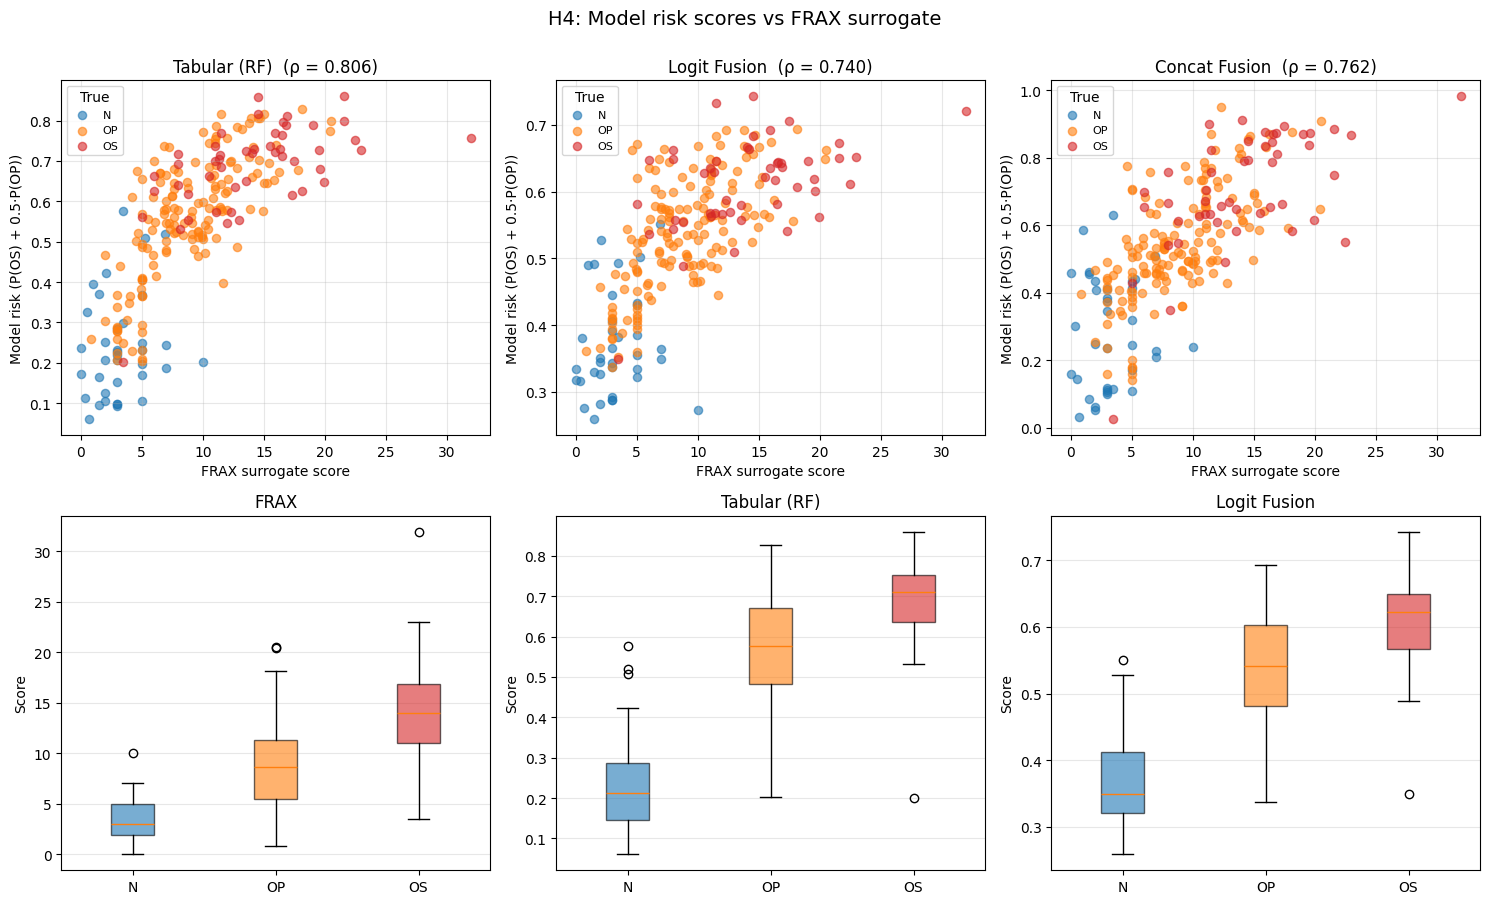


Saved: fig_h4_analysis.png


In [12]:
# ============================================================
# H4: Risk Stratification vs. FRAX Surrogate
#
# Tests whether our model's risk scores align with FRAX-derived
# 10-year fracture risk rankings. Since the dataset lacks
# longitudinal outcomes, we use a simplified FRAX-style score as
# a surrogate ground truth (Kanis et al., 2008).
#
# Three lines of evidence:
#   1. Patient-level Spearman correlation
#   2. Risk-gradient monotonicity (N < OP < OS)
#   3. Visualization (scatter + boxplot)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


# ============================================================
# 1. Simplified FRAX-style risk score (transparent linear combination)
# ============================================================
# This is NOT the proprietary WHO FRAX algorithm. It is a documented
# linear approximation using the same risk factors (age, BMI, sex,
# prior fracture, smoking, family history, postmenopausal years).
def simplified_frax(row):
    """Return a relative 10-year fracture risk score (higher = more risk)."""
    s = 0.0
    age = row.get("age", 50)
    if pd.notna(age):
        s += max(0, age - 40) * 0.4                       # +0.4 per year above 40

    bmi = row.get("bmi", 25)
    if pd.notna(bmi) and bmi < 22:
        s += (22 - bmi) * 0.8                              # low BMI penalty

    if str(row.get("gender", "")).lower() == "female":
        s += 3.0                                           # postmenopausal risk

    ysm = row.get("years_since_menopause", 0)
    if pd.notna(ysm):
        s += ysm * 0.3                                     # estrogen loss proxy

    frac = str(row.get("fracture_severity", "No fracture"))
    s += {"Major": 5.0, "Minor": 2.0, "Unknown fracture": 1.0}.get(frac, 0.0)

    if row.get("smoker", 0) == 1:
        s += 1.5
    if row.get("family_history_of_osteoporosis", 0) == 1:
        s += 2.0

    activity = str(row.get("physical_activity_level", ""))
    s += {"Low": 1.5, "High": -1.0}.get(activity, 0.0)
    return s


print("Computing FRAX-style surrogate scores...")
frax_scores = np.array([simplified_frax(X.iloc[i]) for i in range(len(X))])

# Sanity check: FRAX should monotonically increase across N < OP < OS
print(f"FRAX score by true label:")
for cls in label_encoder.classes_:
    mask = y_encoded == list(label_encoder.classes_).index(cls)
    print(f"  {cls}: mean={frax_scores[mask].mean():.2f} (n={mask.sum()})")


# ============================================================
# 2. Build model risk scores from saved OOF probabilities
# ============================================================
# Risk score = P(OS) + 0.5 * P(OP)
# Rationale: OS is the high-risk state; OP is intermediate risk.
# This continuous risk encoding aligns with FRAX's continuous output.
os_idx = list(label_encoder.classes_).index("OS")
op_idx = list(label_encoder.classes_).index("OP")

def combined_risk(probs):
    return probs[:, os_idx] + 0.5 * probs[:, op_idx]

oof_tab    = np.load("oof_tabular.npy")    # RF tabular
oof_logit  = np.load("oof_fusion.npy")     # logit fusion
oof_concat = np.load("oof_concat.npy")     # concat fusion

model_scores = {
    "Tabular (RF)":   combined_risk(oof_tab),
    "Logit Fusion":   combined_risk(oof_logit),
    "Concat Fusion":  combined_risk(oof_concat),
}


# ============================================================
# 3. Evidence 1: Patient-level rank correlation
# ============================================================
print("\n" + "=" * 60)
print("H4: Spearman correlation between model risk and FRAX")
print("=" * 60)
print(f"{'Model':<20} {'ρ':<10} {'p-value':<12}")
print("-" * 60)
for name, scores in model_scores.items():
    rho, p = spearmanr(scores, frax_scores)
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"{name:<20} {rho:.3f}      {p:.2e}  {sig}")


# ============================================================
# 4. Evidence 2: Risk-gradient consistency (N < OP < OS)
# ============================================================
print("\n" + "=" * 60)
print("Risk-gradient consistency check:")
print("=" * 60)
print(f"{'Model':<20} {'N mean':<10} {'OP mean':<10} {'OS mean':<10} {'order':<8}")
print("-" * 60)
for name, scores in [("FRAX (surrogate)", frax_scores)] + list(model_scores.items()):
    means = [scores[y_encoded == i].mean()
             for i in range(NUM_CLASSES)]
    order = "✓ N<OP<OS" if means[0] < means[1] < means[2] else "✗"
    print(f"{name:<20} {means[0]:.2f}      {means[1]:.2f}      "
          f"{means[2]:.2f}      {order}")


# ============================================================
# 5. Evidence 3: Visualization — scatter + boxplot
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
colors = ['#1f77b4', '#ff7f0e', '#d62728']
class_labels = list(label_encoder.classes_)

# Top row: scatter plots (model vs FRAX)
for ax, (name, scores) in zip(axes[0], model_scores.items()):
    rho, _ = spearmanr(scores, frax_scores)
    for c in range(NUM_CLASSES):
        m = y_encoded == c
        ax.scatter(frax_scores[m], scores[m], alpha=0.6, s=35,
                   color=colors[c], label=class_labels[c])
    ax.set_xlabel("FRAX surrogate score")
    ax.set_ylabel("Model risk (P(OS) + 0.5·P(OP))")
    ax.set_title(f"{name}  (ρ = {rho:.3f})")
    ax.legend(title="True", fontsize=8, loc="best")
    ax.grid(alpha=0.3)

# Bottom row: boxplots (risk score distribution per class)
all_boxes = [("FRAX", frax_scores)] + list(model_scores.items())[:2]  # FRAX + 2 models
for ax, (name, scores) in zip(axes[1], all_boxes):
    data = [scores[y_encoded == i] for i in range(NUM_CLASSES)]
    bp = ax.boxplot(data, labels=class_labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    ax.set_title(name)
    ax.set_ylabel("Score")
    ax.grid(alpha=0.3, axis='y')

plt.suptitle("H4: Model risk scores vs FRAX surrogate", fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig("fig_h4_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: fig_h4_analysis.png")

Training final RF on all data for SHAP analysis...
Computing SHAP values...

TOP 5 FEATURES PER CLASS (mean |SHAP|)

N:
  age                                      0.199
  number_of_pregnancies                    0.047
  years_since_menopause                    0.041
  bmi                                      0.024
  has_cardiovascular                       0.016

OP:
  age                                      0.130
  number_of_pregnancies                    0.056
  bmi                                      0.035
  hypothyroidism                           0.022
  years_since_menopause                    0.021

OS:
  age                                      0.123
  years_since_menopause                    0.040
  gender_male                              0.023
  bmi                                      0.023
  gender_female                            0.021


/tmp/ipykernel_640/3277528674.py:77: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_os, X_all, feature_names=feature_names,


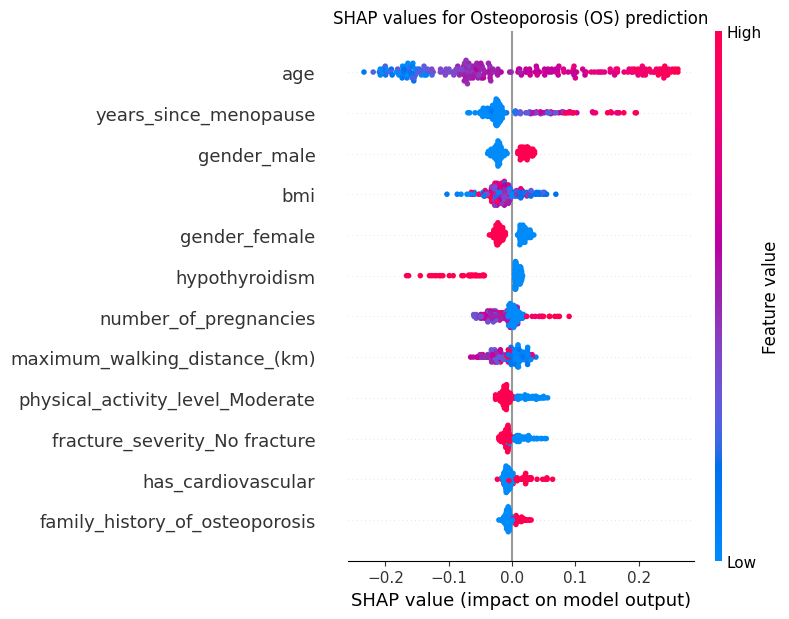

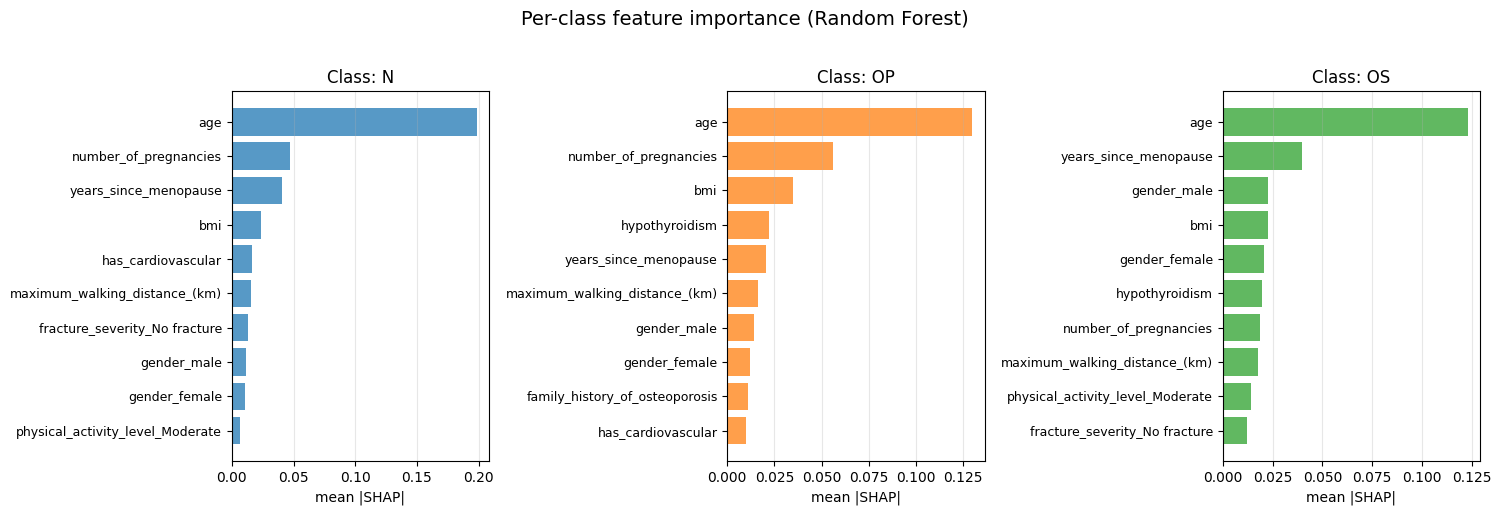


Saved: fig_shap_summary_OS.png, fig_shap_per_class.png


In [13]:
# ============================================================
# SHAP Analysis for the Tabular Branch (Random Forest)
#
# Trains an RF on all data (purely for explainability — no
# evaluation here) and computes per-class SHAP values via
# TreeExplainer. Outputs three figures for the paper.
# ============================================================
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier


# ============================================================
# 1. Train a final RF on all data (for SHAP only)
# ============================================================
# Note: Using all 239 samples is acceptable here because SHAP
# is not used for performance evaluation, only for feature
# attribution. Performance numbers come from the 5-fold CV.
print("Training final RF on all data for SHAP analysis...")
preprocessor = build_preprocessor(feature_groups, scale_numeric=False)
X_all = preprocessor.fit_transform(X)
if hasattr(X_all, "toarray"):
    X_all = X_all.toarray()

rf_shap = RandomForestClassifier(
    n_estimators=300, max_depth=8,
    min_samples_split=4, min_samples_leaf=2,
    max_features="sqrt", class_weight="balanced",
    random_state=42, n_jobs=-1,
)
rf_shap.fit(X_all, y_encoded)


# ============================================================
# 2. Compute SHAP values via TreeExplainer
# ============================================================
print("Computing SHAP values...")
explainer = shap.TreeExplainer(rf_shap)
shap_values = explainer.shap_values(X_all)

# Clean up feature names for display (strip preprocessor prefixes)
feature_names = [
    n.replace("num__", "").replace("cat__", "").replace("bin__", "")
    for n in preprocessor.get_feature_names_out()
]


def get_class_shap(class_name):
    """Return SHAP values for a given class, handling both API formats."""
    cls_idx = list(label_encoder.classes_).index(class_name)
    sv = (shap_values[cls_idx] if isinstance(shap_values, list)
          else shap_values[:, :, cls_idx])
    return sv, cls_idx


# ============================================================
# 3. Print top-5 features per class (for paper text)
# ============================================================
print("\n" + "=" * 60)
print("TOP 5 FEATURES PER CLASS (mean |SHAP|)")
print("=" * 60)
for cls in label_encoder.classes_:
    sv, _ = get_class_shap(cls)
    imp = np.abs(sv).mean(0)
    top = np.argsort(imp)[-5:][::-1]
    print(f"\n{cls}:")
    for i in top:
        print(f"  {feature_names[i]:40s} {imp[i]:.3f}")


# ============================================================
# 4. Figure A: Bee-swarm summary for OS (most clinically relevant class)
# ============================================================
sv_os, _ = get_class_shap("OS")
plt.figure(figsize=(9, 6))
shap.summary_plot(sv_os, X_all, feature_names=feature_names,
                  show=False, max_display=12)
plt.title("SHAP values for Osteoporosis (OS) prediction", fontsize=12)
plt.tight_layout()
plt.savefig("fig_shap_summary_OS.png", dpi=150, bbox_inches='tight')
plt.show()


# ============================================================
# 5. Figure B: Per-class importance comparison (paper hero figure)
# ============================================================
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(15, 5))
bar_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for ax, cls, color in zip(axes, label_encoder.classes_, bar_colors):
    sv, _ = get_class_shap(cls)
    imp = np.abs(sv).mean(0)
    top = np.argsort(imp)[-10:]
    ax.barh(range(len(top)), imp[top], color=color, alpha=0.75)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([feature_names[i] for i in top], fontsize=9)
    ax.set_xlabel("mean |SHAP|")
    ax.set_title(f"Class: {cls}")
    ax.grid(axis='x', alpha=0.3)

plt.suptitle("Per-class feature importance (Random Forest)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("fig_shap_per_class.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: fig_shap_summary_OS.png, fig_shap_per_class.png")

Training DenseNet-121 head on all data for Grad-CAM...
  epoch 5/15 done
  epoch 10/15 done
  epoch 15/15 done
Computing predictions for all 239 samples...
Generating per-class Grad-CAM grid...


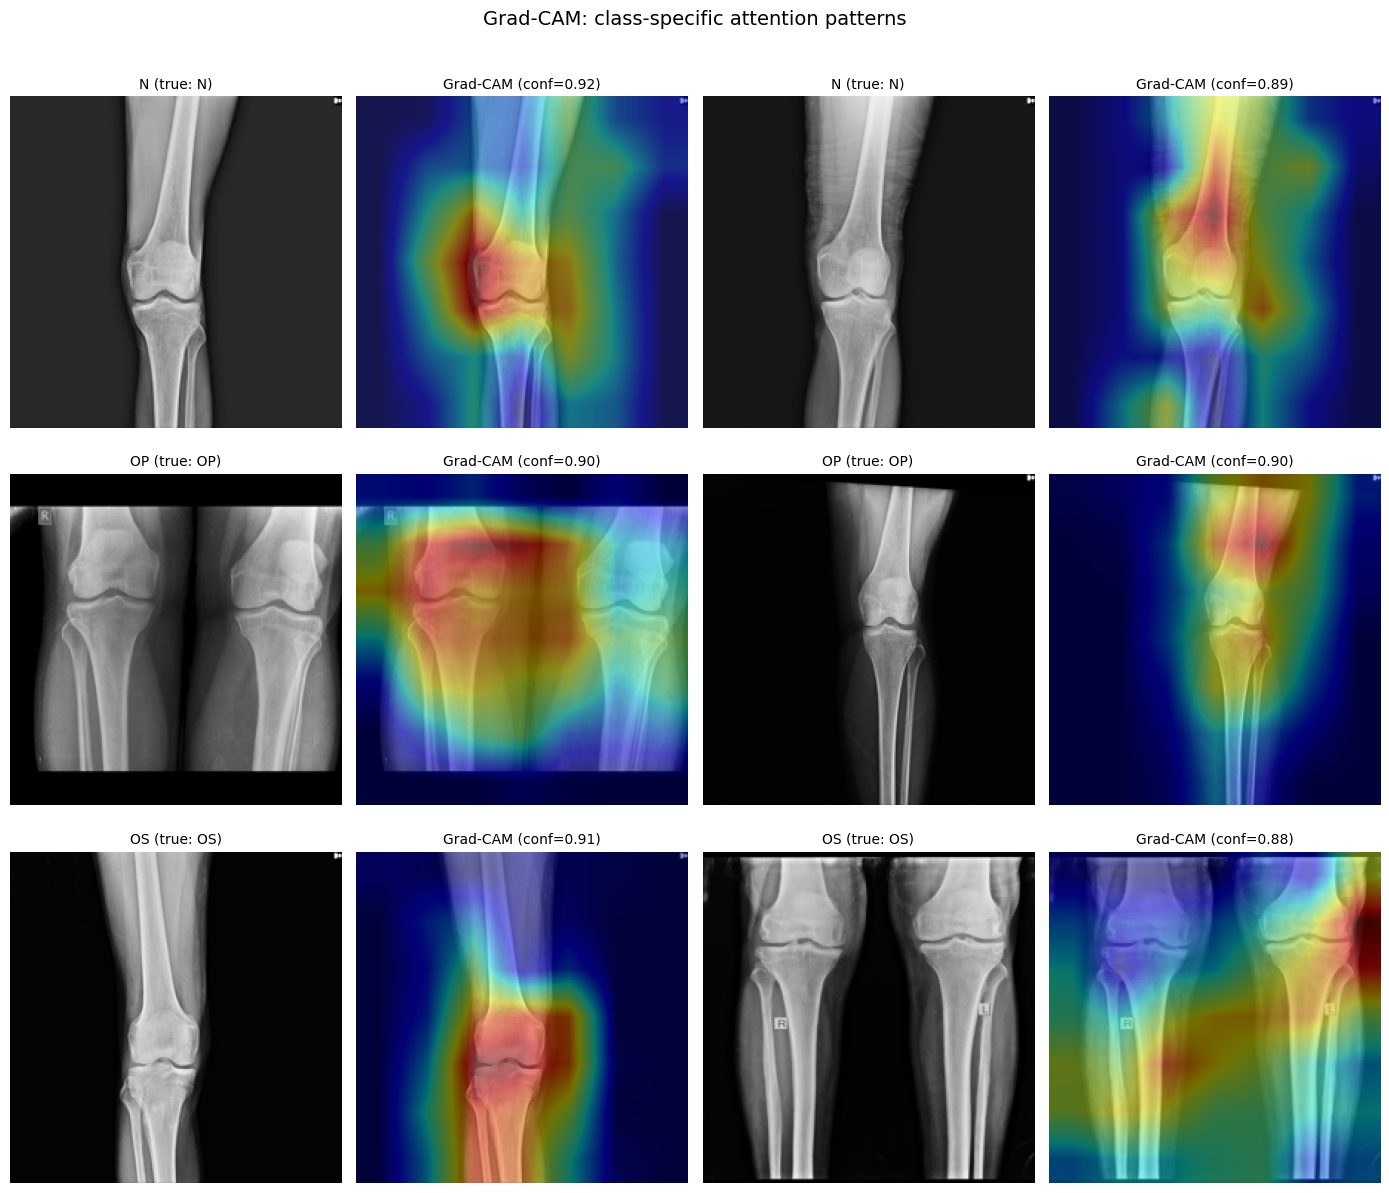

Saved: fig_gradcam_per_class.png


In [18]:
# ============================================================
# Grad-CAM Analysis for the Image Branch
#
# Trains a DenseNet-121 head on all data (for visualization only)
# then computes class-specific attention maps via Grad-CAM on the
# last conv block (features.denseblock4).
#
# Key implementation detail: the model is trained with the backbone
# frozen (requires_grad=False), but Grad-CAM requires gradients to
# flow through `denseblock4`. We therefore re-enable requires_grad
# AFTER training, before running CAM (the model stays in eval mode
# so BatchNorm and Dropout behave correctly).
# ============================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import timm
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


# ============================================================
# 1. Train DenseNet-121 head on all data (for visualization only)
# ============================================================
print("Training DenseNet-121 head on all data for Grad-CAM...")
model_cam = timm.create_model("densenet121", pretrained=True,
                              num_classes=NUM_CLASSES).to(DEVICE)

# Freeze backbone, train head only (same recipe as the image baseline)
for p in model_cam.parameters():
    p.requires_grad = False
for p in model_cam.get_classifier().parameters():
    p.requires_grad = True

cw = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_encoded)
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(cw, dtype=torch.float).to(DEVICE),
    label_smoothing=0.1,
)
opt = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_cam.parameters()),
    lr=1e-3, weight_decay=1e-4,
)

train_loader = DataLoader(
    KneeDataset(images, y_encoded, val_tf),  # val_tf: no augmentation for stable CAM
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
)

for ep in range(15):
    model_cam.train()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        loss = criterion(model_cam(x), y)
        opt.zero_grad(); loss.backward(); opt.step()
    if (ep + 1) % 5 == 0:
        print(f"  epoch {ep + 1}/15 done")


# ============================================================
# 2. Re-enable gradients for Grad-CAM
# ============================================================
# IMPORTANT: Grad-CAM backpropagates from the class score to the
# target conv layer. If backbone params are still frozen, the
# gradient through `denseblock4` is None and CAM fails.
# Setting requires_grad=True here does not modify any weights —
# it only allows gradient computation. eval() keeps Dropout/BN
# in inference mode.
for p in model_cam.parameters():
    p.requires_grad = True
model_cam.eval()

cam = GradCAM(model=model_cam, target_layers=[model_cam.features.denseblock4])


# ============================================================
# 3. Compute predictions and softmax probs for all samples
# ============================================================
print("Computing predictions for all 239 samples...")
all_probs = []
with torch.no_grad():
    for img in images:
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        x = val_tf(img.convert("RGB")).unsqueeze(0).to(DEVICE)
        all_probs.append(torch.softmax(model_cam(x), dim=1).cpu().numpy()[0])
all_probs = np.array(all_probs)
all_preds = all_probs.argmax(1)


# ============================================================
# 4. Helper: overlay heat-map on original image
# ============================================================
def cam_overlay(img_pil, mask):
    """Return (original_resized, heatmap_overlay) both as RGB float arrays."""
    img_np = np.array(img_pil.convert("RGB").resize((IMG_SIZE, IMG_SIZE))) / 255.0
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
    heat = plt.cm.jet(mask)[..., :3]
    return img_np, np.clip(0.55 * img_np + 0.45 * heat, 0, 1)


# ============================================================
# 5. Figure: 3 classes × 2 high-confidence samples each
# ============================================================
print("Generating per-class Grad-CAM grid...")
fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(14, 4 * NUM_CLASSES))

for cls_idx, cls_name in enumerate(label_encoder.classes_):
    # Prefer correctly-predicted high-confidence samples; fall back if needed
    correct = np.where((all_preds == cls_idx) & (y_encoded == cls_idx))[0]
    if len(correct) < 2:
        correct = np.where(y_encoded == cls_idx)[0]
    top2 = correct[np.argsort(all_probs[correct, cls_idx])[-2:][::-1]]

    for col, sample_idx in enumerate(top2):
        img = images[sample_idx]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        x = val_tf(img.convert("RGB")).unsqueeze(0).to(DEVICE)
        mask = cam(input_tensor=x, targets=[ClassifierOutputTarget(cls_idx)])[0]
        img_np, overlay = cam_overlay(img, mask)

        axes[cls_idx, col*2].imshow(img_np)
        axes[cls_idx, col*2].set_title(
            f"{cls_name} (true: {label_encoder.classes_[y_encoded[sample_idx]]})",
            fontsize=10,
        )
        axes[cls_idx, col*2].axis('off')

        axes[cls_idx, col*2 + 1].imshow(overlay)
        axes[cls_idx, col*2 + 1].set_title(
            f"Grad-CAM (conf={all_probs[sample_idx, cls_idx]:.2f})",
            fontsize=10,
        )
        axes[cls_idx, col*2 + 1].axis('off')

plt.suptitle("Grad-CAM: class-specific attention patterns",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("fig_gradcam_per_class.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_gradcam_per_class.png")